## Problem Statement

Pneumonia is a life-threatening respiratory infection that affects millions of people worldwide each year, particularly children, elderly individuals, and immunocompromised patients. Early and accurate diagnosis is critical for timely treatment and reducing mortality rates. Chest X-ray imaging is one of the most commonly used diagnostic tools for detecting pneumonia. However, manual interpretation of X-ray images is time-consuming and highly dependent on the expertise of radiologists, which can lead to delayed diagnosis or misclassification, especially in resource-constrained healthcare settings.

The increasing burden on healthcare systems highlights the need for automated and reliable diagnostic support systems. Traditional machine learning approaches often require handcrafted feature extraction and may fail to capture complex patterns present in medical images.

Therefore, the problem addressed in this study is the development of an automated deep learning-based system capable of accurately classifying chest X-ray images into two categories: **Pneumonia** and **Normal**. The proposed system aims to leverage transfer learning techniques using a pre-trained convolutional neural network to improve diagnostic accuracy, reduce dependency on manual interpretation, and provide a scalable solution for real-time clinical decision support.


### IMPORTING THE LIBRARY

In [1]:
import tensorflow as tf 
from tensorflow.keras.layers import Dropout,Conv2D,MaxPooling2D,GlobalAveragePooling2D,Dense
from tensorflow.keras import Sequential , layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau,ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-04-01 03:48:08.444254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775015288.629118      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775015288.689259      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775015289.130837      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775015289.130882      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775015289.130885      55 computation_placer.cc:177] computation placer alr

## Data Augmentation Strategy

To enhance model generalization and reduce overfitting, real-time data augmentation was applied to the training dataset using TensorFlow/Keras image preprocessing utilities.

### Training Data Preprocessing

The following transformations were applied to the training images:

- **Rescaling:** Pixel values were normalized to the range \([0,1]\) by dividing by 255.
- **Rotation:** Random rotations up to ±20°.
- **Zooming:** Random zoom within a range of 20%.
- **Width Shift:** Horizontal translation up to 10%.
- **Height Shift:** Vertical translation up to 10%.
- **Horizontal Flip:** Random horizontal flipping.
- **Fill Mode:** Nearest-neighbor interpolation was used to fill newly created pixels.

These augmentations were applied dynamically during training to improve robustness and prevent overfitting.

### Test Data Preprocessing

For the test dataset, only normalization was applied:

- **Rescaling:** Pixel values were normalized to the range \([0,1]\).

No augmentation techniques were applied to the test data to ensure unbiased and fair performance evaluation.

---

### Implementation Details Below
```


In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255)

## Dataset Preparation and Loading

The dataset used in this study is the Chest X-ray Pneumonia dataset obtained from Kaggle. The images were organized into directory-based class folders and loaded using TensorFlow/Keras `flow_from_directory()` utility.

### Data Loading Configuration

The images were resized to \(224 \times 224\) pixels to match the input requirements of standard CNN architectures. A batch size of 32 was used during training and testing.

- **Target Image Size:** 224 × 224
- **Batch Size:** 32
- **Class Mode:** Binary (Pneumonia vs Normal)
- **Shuffle:** Enabled for both training and testing datasets

### Training Data Loader

The training images were loaded from the directory:

`/kaggle/input/chest-xray-pneumonia/chest_xray/train`

### Test Data Loader

The test images were loaded from the directory:

`/kaggle/input/chest-xray-pneumonia/chest_xray/test`

---

### Implementation Code Below 



In [3]:
from tensorflow.keras import regularizers

In [4]:
train_generator = train_datagen.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

Found 5216 images belonging to 2 classes.


In [5]:
test_generator = test_datagen.flow_from_directory(
    "/kaggle/input/chest-xray-pneumonia/chest_xray/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

Found 624 images belonging to 2 classes.


## Transfer Learning Using ResNet50

To leverage pre-trained feature representations, transfer learning was employed using the ResNet50 architecture. The model was initialized with ImageNet pre-trained weights to utilize learned low-level and high-level image features.

### Model Configuration

- **Architecture:** ResNet50
- **Pre-trained Weights:** ImageNet
- **Include Top Layer:** No (Fully connected classification head removed)
- **Input Shape:** 224 × 224 × 3
- **Trainable Parameters:** Frozen (Feature extractor mode)

The convolutional base was frozen to prevent weight updates during initial training, allowing the model to act as a fixed feature extractor.

---

### Implementation Code Below

### Experimental Description 

> Transfer learning was applied using the ResNet50 architecture pre-trained on the ImageNet dataset. The top fully connected classification layers were removed, and the convolutional base was used as a fixed feature extractor. All pre-trained layers were frozen during the initial training phase to preserve learned representations and reduce computational complexity.


In [6]:
base_model=ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable=False

I0000 00:00:1775015317.107023      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775015317.112786      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Proposed Model Architecture

After initializing the pre-trained ResNet50 model as a fixed feature extractor, a custom classification head was added to perform binary classification (Pneumonia vs Normal).

### Architecture Design

The following layers were appended to the frozen convolutional base:

1. **Global Average Pooling (GAP):**  
   Reduces spatial dimensions while preserving essential feature information.

2. **Batch Normalization:**  
   Stabilizes and accelerates training by normalizing activations.

3. **Dropout (0.5):**  
   Prevents overfitting by randomly disabling 50% of neurons during training.

4. **Dense Layer (128 units, ReLU activation):**  
   Learns task-specific high-level feature representations.

5. **Dropout (0.3):**  
   Additional regularization to further reduce overfitting.

6. **Output Layer (1 unit, Sigmoid activation):**  
   Produces probability scores for binary classification.

---

### Implementation Code Below 

###  Description

> A custom classification head was added on top of the frozen ResNet50 convolutional base. Global Average Pooling was used to reduce spatial dimensions and minimize overfitting. Batch normalization and dropout layers were incorporated for improved generalization and training stability. A fully connected dense layer with 128 neurons and ReLU activation was used for feature learning, followed by a sigmoid-activated output layer for binary classification.


In [7]:

model=Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(layers.BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(256,activation="relu",kernel_regularizer=regularizers.l2(0.002)))
model.add(Dropout(0.3))
model.add(Dense(128,activation="relu",kernel_regularizer=regularizers.l2(0.002)))
model.add(Dropout(0.3))
model.add(Dense(1,activation="sigmoid"))



In [8]:
model.compile(metrics=['accuracy'],optimizer="adam",loss='binary_crossentropy')

## Training Strategy and Callbacks

To enhance model convergence and prevent overfitting, multiple callback mechanisms were employed during training.

### 1. Early Stopping

Early stopping was used to halt training when the validation loss stopped improving. This prevents unnecessary training and reduces overfitting.

- **Monitor:** Validation Loss (`val_loss`)
- **Patience:** 5 epochs
- **Restore Best Weights:** Enabled
- **Mode:** Auto

### 2. Learning Rate Reduction

A dynamic learning rate scheduler was applied using ReduceLROnPlateau to decrease the learning rate when validation performance plateaued.

- **Monitor:** Validation Loss (`val_loss`)
- **Reduction Factor:** 0.2
- **Minimum Learning Rate:** 1e-6

### 3. Model Checkpointing

ModelCheckpoint was used to save the best-performing model based on validation loss.

- **Save Best Only:** Enabled
- **Monitoring Metric:** Validation Loss
- **Mode:** Minimum

---

### Implementation Code Below 

### Decription 
> To ensure optimal convergence and prevent overfitting, EarlyStopping was implemented with a patience of five epochs based on validation loss. Additionally, a ReduceLROnPlateau scheduler was used to dynamically decrease the learning rate by a factor of 0.2 when validation loss plateaued, with a minimum threshold of 1e-6. The best-performing model was saved using ModelCheckpoint based on minimum validation loss.


In [9]:
early=EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=3,
    restore_best_weights=True,
    mode="auto"
)


In [10]:
reduce=ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    min_lr=1e-6,
    verbose=1
)

In [11]:

checkpoint = ModelCheckpoint(
    'best_Resenet_modelDT.keras', 
    monitor='val_loss', 
    save_best_only=True, 
    mode='min', 
    verbose=1
)

## Model Training

The model was trained using the augmented training dataset for 20 epochs. The number of steps per epoch was calculated based on the total number of training samples divided by the batch size (32).

Validation was performed on the test dataset at the end of each epoch to monitor generalization performance.

In [12]:
history=model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//32,
    epochs=20,
    validation_steps=test_generator.samples // 32,
    validation_data=test_generator,
    callbacks=[early,reduce,checkpoint]

  
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1775015341.767868     139 service.cc:152] XLA service 0x7832d80146e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775015341.767905     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775015341.767909     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775015344.018781     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/163 ━━━━━━━━━━━━━━━━━━━━ 43:50 16s/step - accuracy: 0.5000 - loss: 1.9883

I0000 00:00:1775015350.210916     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.8127 - loss: 1.0998
Epoch 1: val_loss improved from inf to 0.95408, saving model to best_Resenet_modelDT.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 146s 801ms/step - accuracy: 0.8128 - loss: 1.0982 - val_accuracy: 0.6217 - val_loss: 0.9541 - learning_rate: 0.0010
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.8655 - loss: 0.6017
Epoch 2: val_loss improved from 0.95408 to 0.72599, saving model to best_Resenet_modelDT.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 581ms/step - accuracy: 0.8655 - loss: 0.6015 - val_accuracy: 0.6743 - val_loss: 0.7260 - learning_rate: 0.0010
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.8786 - loss: 0.4908
Epoch 3: val_loss improved from 0.72599 to 0.61797, saving model to best_Resenet_modelDT.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 577ms/step - accuracy: 0.8785 - loss: 0.4907 - val_accuracy: 0.7648 - val_loss: 0.6180 - learning_rate: 0.0010
Epoch 4/20
163/163 ━━━━━━━━━━━━━━

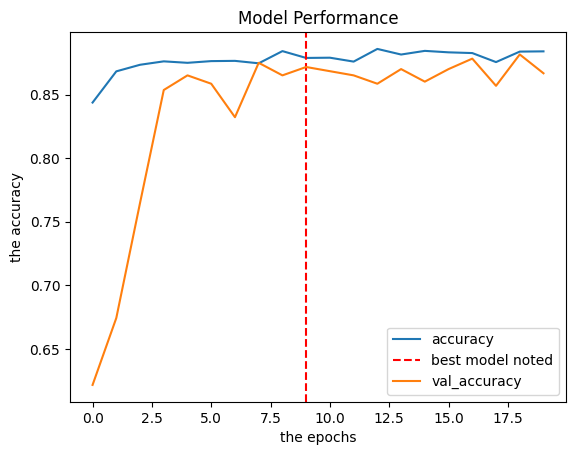

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label="accuracy")
plt.axvline(x=9,linestyle="--",label="best model noted",color="red")
plt.plot(history.history['val_accuracy'],label="val_accuracy")
plt.xlabel("the epochs")
plt.ylabel("the accuracy")
plt.title("Model Performance")
plt.legend()
plt.show()

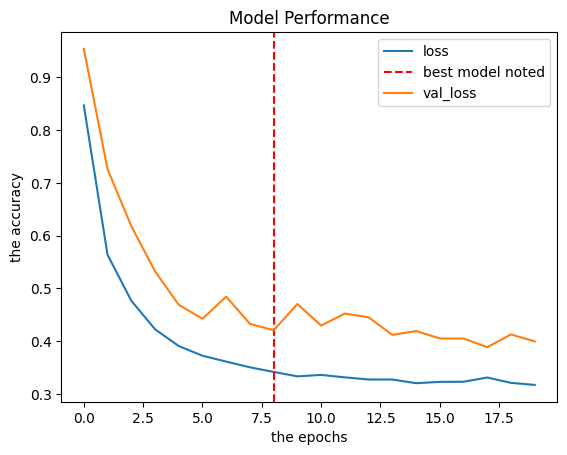

In [17]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],label="loss")
plt.axvline(x=8,linestyle="--",label="best model noted",color="red")
plt.plot(history.history['val_loss'],label="val_loss")
plt.xlabel("the epochs")
plt.ylabel("the accuracy")
plt.title("Model Performance")
plt.legend()
plt.show()

In [15]:
import gradio as gr
import numpy as np
import tensorflow as tf

def gradio_predict(image):
    # Resize to training size
    image = image.resize((224, 224))
    
    # Convert to numpy and normalize
    img_array = np.array(image) / 255.0
    
    # If grayscale model, uncomment next line
    # img_array = np.expand_dims(img_array, axis=-1)
    
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)[0][0]

    return {
        "Normal": float(1 - prediction),
        "Pneumonia": float(prediction)
    }

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=2),
    title="🩺 Chest X-ray Pneumonia Detection",
    description="Upload a chest X-ray image to classify."
)

demo.launch(share=True, inline=False)


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a029ab2859d0768b85.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
base_model.trainable = True

In [ ]:
fine_tune_at = int(len(base_model.layers) * 0.75)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [ ]:
history=model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//32,
    epochs=20,
    validation_steps=test_generator.samples // 32,
    validation_data=test_generator,
    callbacks=[early,reduce,checkpoint]

  
)

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf

def gradio_predict(image):

    # Resize image
    image = image.resize((224, 224))

    # Convert to numpy
    img_array = np.array(image) / 255.0

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)[0][0]

    normal_prob = float(1 - prediction)
    pneumonia_prob = float(prediction)

    # AI Message
    if pneumonia_prob > 0.5:
        message = """
🚨 **Possible Pneumonia Detected**

The AI model predicts that this chest X-ray may show signs of pneumonia.

⚠️ Pneumonia is a lung infection that can cause:
• Chest pain  
• Difficulty breathing  
• Fever and cough  

👉 **Please consult a medical professional immediately for proper diagnosis and treatment.**
"""
    else:
        message = """
✅ **AI Prediction: Normal**

The AI model predicts this X-ray appears normal.

⚠️ However, **AI predictions are not a medical diagnosis.**  
Please consult a **qualified doctor or radiologist** for confirmation.
"""

    return {"Normal": normal_prob, "Pneumonia": pneumonia_prob}, message


# Black + Blue Theme UI
with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="blue",
        neutral_hue="slate"
    )
) as demo:

    gr.Markdown(
        """
        # 🩺 Chest X-ray Pneumonia Detection
        Upload a chest X-ray image to classify whether it shows **Normal lungs or Pneumonia**.
        """
    )

    with gr.Row():
        image_input = gr.Image(type="pil", label="Upload Chest X-ray")

    predict_btn = gr.Button("Analyze X-ray", variant="primary")

    output_label = gr.Label(num_top_classes=2, label="Prediction")
    output_text = gr.Markdown()

    predict_btn.click(
        fn=gradio_predict,
        inputs=image_input,
        outputs=[output_label, output_text]
    )

demo.launch(share=True)

In [ ]:
model.save("onem.keras")

## Model Performance Analysis

The model achieved approximately **90% training accuracy** and **88% validation accuracy**.  
The validation loss exhibited minor fluctuations but remained stable throughout the training process, indicating effective generalization and the absence of significant overfitting.


model.save("")

In [ ]:
model.save("DTcnn.h5")